In [22]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import shutil
import pandas as pd
import numpy as np
print(os.getcwd())

c:\Users\Admin\Desktop\FaID-System\src\preprocess


In [23]:
RAW_FOLDER = os.path.join(os.path.dirname(os.path.dirname(os.getcwd())),"data","raw","webface_112x112")
PROCESSED_FOLDER = os.path.join(os.path.dirname(os.path.dirname(os.getcwd())),"data","processed","webface_112x112")

In [24]:
def view(folder: str) -> None:
    if os.path.exists(folder):
        identities = os.listdir(folder)
        counts = []

        for i in identities:
            path = os.path.join(folder, i)
            if os.path.isdir(path):
                num_images = sum(
                    1
                    for f in os.listdir(path)
                    if f.lower().endswith((".jpg", ".png", ".jpeg"))
                )
                if num_images > 0:
                    counts.append(num_images)

        if not counts:
            print(f"Không tìm thấy ảnh trong thư mục: {folder}.")
            return

        mean = sum(counts) / len(counts)
        sorted_counts = sorted(counts)
        median = sorted_counts[len(counts) // 2]
        min_val, max_val = min(counts), max(counts)
        total = sum(counts)

        sns.set_theme(style="whitegrid")
        fig, axes = plt.subplots(1, 3, figsize=(20, 7))
        plt.subplots_adjust(wspace=0.3)

        sns.boxplot(x=counts, color="lightgreen", ax=axes[0])
        axes[0].set_title("Biểu đồ độ phân tán dữ liệu", fontsize=14)
        axes[0].set_xlabel("Số lượng mẫu/ID")

        sns.ecdfplot(counts, color="darkorange", linewidth=2.5, ax=axes[1])
        axes[1].set_title("Biểu đồ phân phối tích lũy", fontsize=14)
        axes[1].set_xlabel("Số lượng mẫu/ID")
        axes[1].set_ylabel("Tỉ lệ tích lũy")

        labels = ["Min", "Mean", "Median", "Max"]
        values = [min_val, mean, median, max_val]
        colors = ["#ff9999", "#66b3ff", "#99ff99", "#ffcc99"]

        axes[2].bar(labels, values, color=colors, width=0.6)

        for i, v in enumerate(values):
            axes[2].text(
                i,
                v + (max_val * 0.02),
                f"{v:.1f}" if i == 1 else f"{int(v)}",
                ha="center",
                fontweight="bold",
                fontsize=11,
            )

        axes[2].set_title(f"Thống kê tổng quát ({total} ảnh)", fontsize=14)
        axes[2].set_ylim(0, max_val * 1.2)

        plt.suptitle(
            f"Phân tích dữ liệu bộ mẫu: {os.path.basename(folder)} ({len(counts)} ID)",
            fontsize=16,
            fontweight="bold",
            y=1.05,
        )
        plt.show()
    else:
        print(f"Không tìm thấy thư mục: {folder}")

In [25]:
import os
import shutil
import numpy as np
import pandas as pd

def make_dataset(src_dir, dst_dir, median, target) -> None:
    if not os.path.exists(src_dir):
        print(f"Không tìm thấy thư mục: {src_dir}")
        return

    if os.path.exists(dst_dir):
        shutil.rmtree(dst_dir)
    os.makedirs(dst_dir)        
    
    infos = []
    for i in os.listdir(src_dir):
        id_dir = os.path.join(src_dir, i)
        if os.path.isdir(id_dir):
            images = [
                f.name for f in os.scandir(id_dir)
                if f.is_file() and f.name.lower().endswith((".jpg", ".png", ".jpeg"))
            ]
            if images:
                diff = abs(len(images) - median)
                infos.append({"name": i, "images": images, "count": len(images), "diff": diff})

    infos.sort(key=lambda x: x["diff"])

    selected_ids = []
    temp_total = 0
    for item in infos:
        std_dev = median / 2 
        prob = np.exp(-0.5 * ((item["count"] - median) / std_dev) ** 2)
        take_count = int(max(1, median * prob)) 
        take_count = min(take_count, item["count"])
        
        if take_count < (median * 0.3): continue
            
        item['take_count'] = take_count 
        selected_ids.append(item)
        temp_total += take_count
        if temp_total >= target: break

    if not selected_ids:
        print("Không có data phù hợp")
        return

    np.random.seed(42)
    np.random.shuffle(selected_ids) 
    
    num_ids = len(selected_ids)
    mix_id_end = int(num_ids * 0.9)

    final_data = []
    
    for idx, item in enumerate(selected_ids):
        new_id_name = str(idx) 
        new_id_path = os.path.join(dst_dir, new_id_name)
        os.makedirs(new_id_path, exist_ok=True)

        selected_images = item["images"][:item['take_count']]
        np.random.shuffle(selected_images)

        if idx < mix_id_end:
            img_split_idx = int(len(selected_images) * 0.8)
            
            for img_idx, f in enumerate(selected_images):
                split_type = "train" if img_idx < img_split_idx else "val"
                
                src_path = os.path.join(src_dir, item["name"], f)
                dst_path = os.path.join(new_id_path, f)
                shutil.copy(src_path, dst_path) 

                final_data.append({
                    "filepath": os.path.join(new_id_name, f),
                    "label": idx,
                    "original": item["name"],
                    "split": split_type 
                })
        else:
            for f in selected_images:
                src_path = os.path.join(src_dir, item["name"], f)
                dst_path = os.path.join(new_id_path, f)
                shutil.copy(src_path, dst_path) 

                final_data.append({
                    "filepath": os.path.join(new_id_name, f),
                    "label": idx,
                    "original": item["name"],
                    "split": "test" 
                })

    df = pd.DataFrame(final_data)
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)
    df.to_excel(os.path.join(dst_dir, "metadata.xlsx"), index=False)
    print(f"Hoàn thành! Tổng cộng {num_ids} IDs. Mix IDs: {mix_id_end}, Test IDs: {num_ids - mix_id_end}")

In [26]:
make_dataset(RAW_FOLDER, PROCESSED_FOLDER,27,50000)

Hoàn thành! Tổng cộng 1978 IDs. Mix IDs: 1780, Test IDs: 198


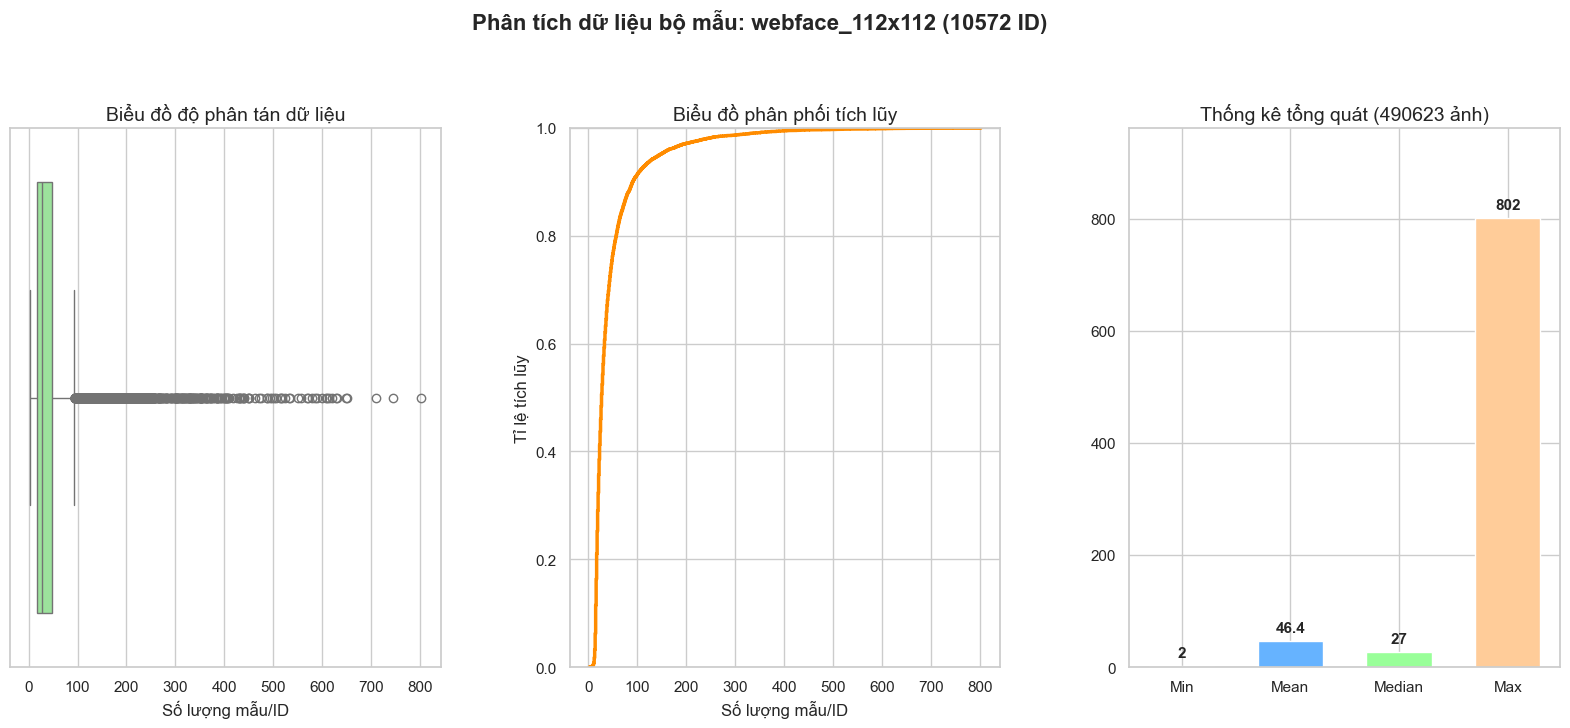

In [27]:
view(RAW_FOLDER)

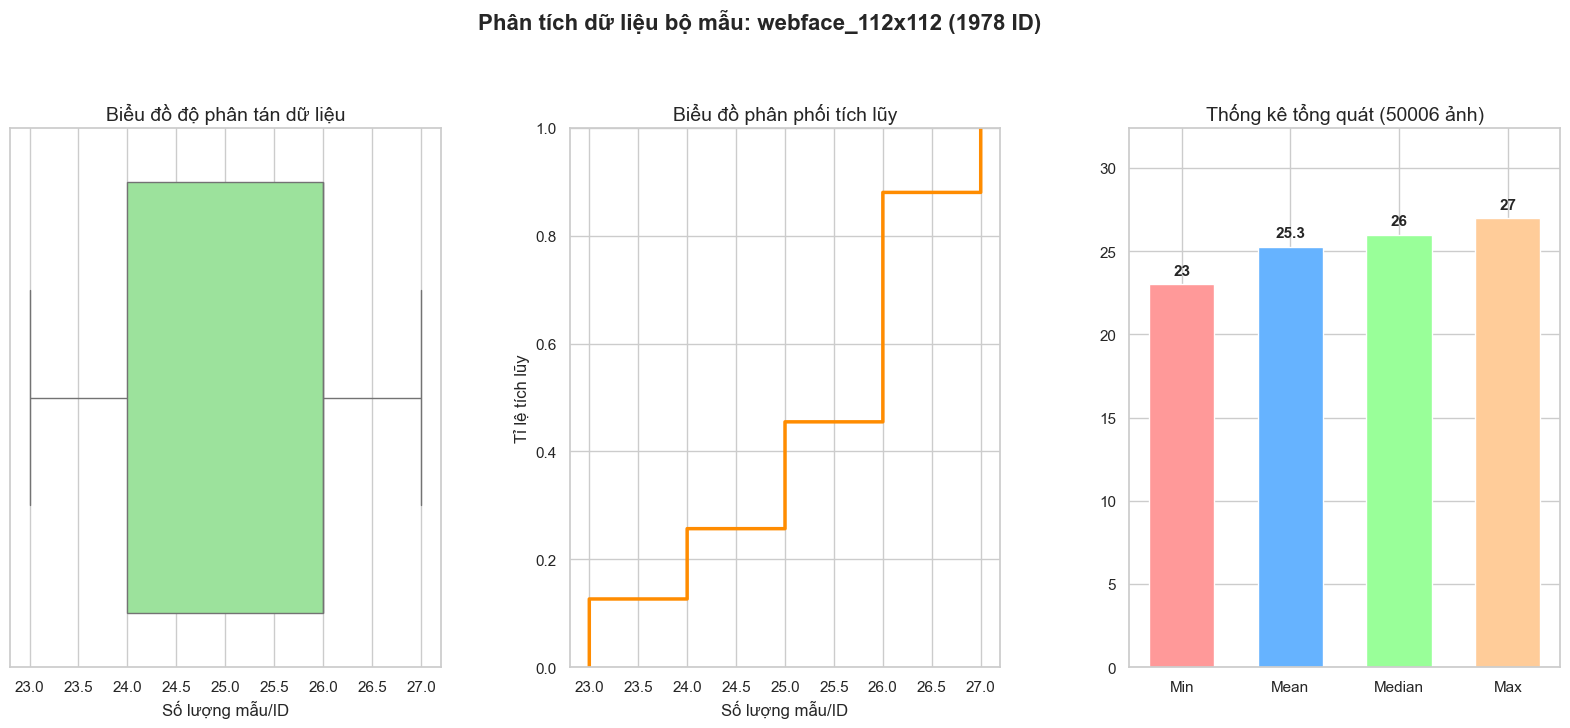

In [28]:
view(PROCESSED_FOLDER)